In [1]:
!pip install pennylane

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aklimarimi/8-facial-expressions-for-yolo")

print("Path to dataset files:", path)

Resuming download from 1171259392 bytes (2877824730 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/aklimarimi/8-facial-expressions-for-yolo?dataset_version_number=4 (1171259392/4049084122) bytes left.


100%|██████████| 3.77G/3.77G [00:32<00:00, 87.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aklimarimi/8-facial-expressions-for-yolo/versions/4


In [3]:
import os
import torch
import torchvision
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
%matplotlib inline

DATA_DIR = '/root/.cache/kagglehub/datasets/aklimarimi/8-facial-expressions-for-yolo/versions/4/9 Facial Expressions you need'
train = os.listdir(os.path.join(DATA_DIR,'train'))
test = os.listdir(os.path.join(DATA_DIR,'test'))
val=os.listdir(os.path.join(DATA_DIR,'valid'))
print(f'Train - {train}')
print(f'Test - {test}')
print(f'Val - {val}')

Train - ['labels', 'images']
Test - ['labels', 'images']
Val - ['labels', 'images']


In [4]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 48
EMOTIONS = ['Happy', 'Sad', 'Angry', 'Surprised', 'Neutral', 'Disgusted', 'Fear', 'Sleepy', 'Contempt']  # update based on your labels
emotion_to_idx = {e: i for i, e in enumerate(EMOTIONS)}
idx_to_emotion = {i: e for i, e in enumerate(EMOTIONS)} # Add mapping from index to emotion

def load_data(folder_path):
    image_dir = os.path.join(folder_path, 'images')
    label_dir = os.path.join(folder_path, 'labels')

    images = []
    labels = []

    # Get list of label files
    label_files = sorted([f for f in os.listdir(label_dir) if f.endswith('.txt')])

    for label_fname in label_files:
        image_fname = label_fname.replace('.txt', '.jpg')
        image_path = os.path.join(image_dir, image_fname)
        label_path = os.path.join(label_dir, label_fname)

        # Check if the corresponding image file exists
        if not os.path.exists(image_path):
            print(f"Warning: Image file not found for label file {label_path}. Skipping.")
            continue

        # Load image in grayscale
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: Could not read image file {image_path}. Skipping.")
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to 48×48
        images.append(img)

        # Load and parse label from YOLO format
        with open(label_path, 'r') as f:
            label_content = f.read().strip()
            # Assuming the first number in the line is the class ID
            try:
                class_id = int(label_content.split()[0])
                labels.append(class_id)
            except (ValueError, IndexError):
                print(f"Warning: Could not parse label from file {label_path}. Content: '{label_content}'. Skipping.")
                images.pop() # Remove the image if label parsing fails
                continue


    images = np.array(images)
    labels = np.array(labels)
    return images, labels


# Load full data from train folder
images, labels = load_data(os.path.join(DATA_DIR, 'test'))

# Normalize pixel values to be between 0 and 1
images = images / 255.0

# Reduce dataset size
n_train = 5000
n_test = 3000

train_images = images[:n_train]
train_labels = labels[:n_train]
test_images = images[-n_test:]
test_labels = labels[-n_test:]

# Add grayscale channel dimension: (N, 48, 48, 1)
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

# One-hot encode the labels
train_labels_categorical = to_categorical(train_labels, num_classes=len(EMOTIONS))
test_labels_categorical = to_categorical(test_labels, num_classes=len(EMOTIONS))

# Final checks
print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Train labels shape: {train_labels_categorical.shape}")
print(f"Test labels shape: {test_labels_categorical.shape}")

Train images shape: (1700, 48, 48, 1)
Test images shape: (1700, 48, 48, 1)
Train labels shape: (1700, 9)
Test labels shape: (1700, 9)


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(



=== Running for 10 Qubits ===

Quantum Circuit for 10 Qubits:


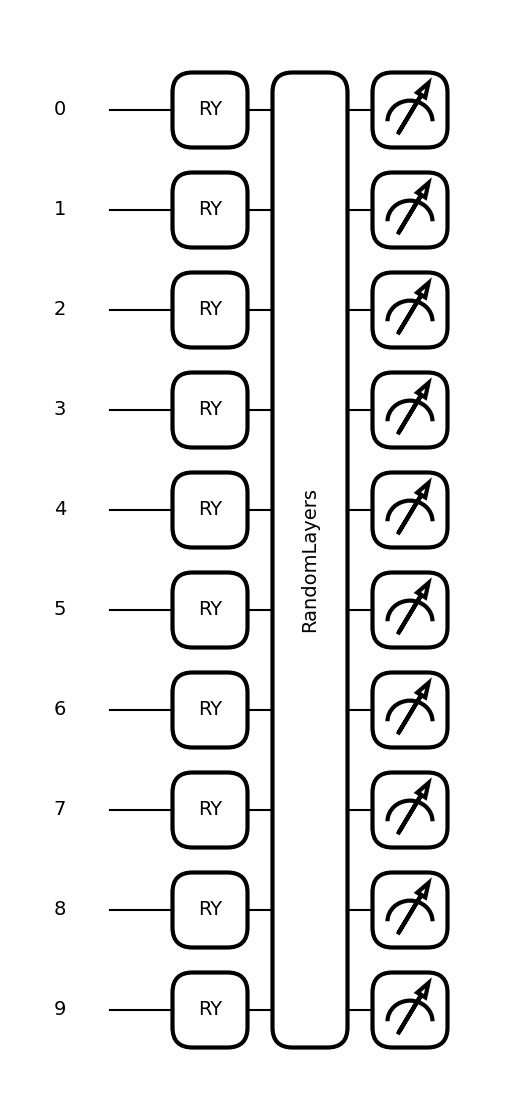

Quantum preprocessing (train)...
Quantum preprocessing (test)...


In [5]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Number of classes (for this dataset)
num_classes = len(EMOTIONS)

# Define qubit patch sizes
qubit_patch_shapes = {
    4: (2, 2),
    6: (3, 2),
    8: (4, 2),
    10: (5, 2),
    12: (4, 3),
}

# ------------------ Quantum Circuit Creation -------------------
def create_circuit(n_qubits, n_layers=1):
    dev = qml.device("default.qubit", wires=n_qubits)
    rand_params = np.random.uniform(high=2*np.pi, size=(n_layers, n_qubits))

    @qml.qnode(dev)
    def circuit(phi):
        # Encode classical data into qubits
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)
        RandomLayers(rand_params, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]

    return circuit

# ------------------ Quantum Convolution -------------------
def quanv(image, circuit, patch_h, patch_w):
    out_h = (image.shape[0] - patch_h) // 2 + 1
    out_w = (image.shape[1] - patch_w) // 2 + 1
    n_qubits = patch_h * patch_w
    out = np.zeros((out_h, out_w, n_qubits))
    for j in range(0, image.shape[0] - patch_h + 1, 2):
        for k in range(0, image.shape[1] - patch_w + 1, 2):
            patch = image[j:j+patch_h, k:k+patch_w, 0].flatten()
            q_results = circuit(patch)
            out[j//2, k//2, :] = q_results
    return out

def build_model(input_shape, num_classes):
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=input_shape),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

results = {}
n_qubits=10

print(f"\n=== Running for {n_qubits} Qubits ===")
patch_h, patch_w = qubit_patch_shapes[n_qubits]
circuit = create_circuit(n_qubits)

# Show quantum circuit diagram
print(f"\nQuantum Circuit for {n_qubits} Qubits:")
fig, ax = qml.draw_mpl(circuit)(np.random.rand(n_qubits))
plt.show()

# Quantum preprocessing
print("Quantum preprocessing (train)...")
q_train_images = np.array([quanv(img, circuit, patch_h, patch_w) for img in train_images])
print("Quantum preprocessing (test)...")
q_test_images = np.array([quanv(img, circuit, patch_h, patch_w) for img in test_images])

 Running Quantum CNN for Seed = 0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 5s - 25ms/step - accuracy: 0.2282 - loss: 2.3220 - val_accuracy: 0.3247 - val_loss: 1.8532
Epoch 2/250
213/213 - 3s - 15ms/step - accuracy: 0.2871 - loss: 1.9233 - val_accuracy: 0.3976 - val_loss: 1.7180
Epoch 3/250
213/213 - 2s - 10ms/step - accuracy: 0.3171 - loss: 1.7981 - val_accuracy: 0.4524 - val_loss: 1.6038
Epoch 4/250
213/213 - 2s - 10ms/step - accuracy: 0.3629 - loss: 1.6710 - val_accuracy: 0.4924 - val_loss: 1.4458
Epoch 5/250
213/213 - 2s - 10ms/step - accuracy: 0.4076 - loss: 1.6008 - val_accuracy: 0.5359 - val_loss: 1.3863
Epoch 6/250
213/213 - 2s - 10ms/step - accuracy: 0.4312 - loss: 1.4904 - val_accuracy: 0.5718 - val_loss: 1.2671
Epoch 7/250
213/213 - 3s - 14ms/step - accuracy: 0.4653 - loss: 1.4233 - val_accuracy: 0.5918 - val_loss: 1.1755
Epoch 8/250
213/213 - 2s - 11ms/step - accuracy: 0.4947 - loss: 1.3533 - val_accuracy: 0.6235 - val_loss: 1.1055
Epoch 9/250
213/213 - 2s - 10ms/step - accuracy: 0.5224 - loss: 1.2777 - val_accuracy: 0.6524 - 

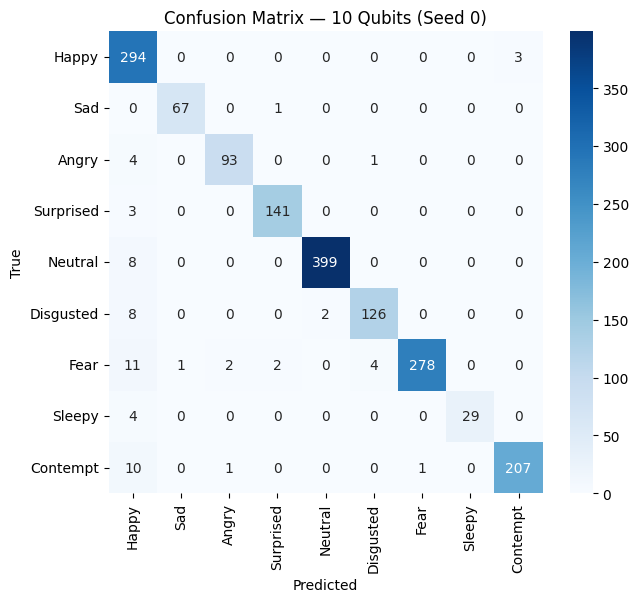

 Running Quantum CNN for Seed = 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 3s - 16ms/step - accuracy: 0.2218 - loss: 2.3229 - val_accuracy: 0.3112 - val_loss: 1.8511
Epoch 2/250
213/213 - 2s - 10ms/step - accuracy: 0.3035 - loss: 1.9047 - val_accuracy: 0.3965 - val_loss: 1.6660
Epoch 3/250
213/213 - 3s - 12ms/step - accuracy: 0.3347 - loss: 1.7813 - val_accuracy: 0.4435 - val_loss: 1.5622
Epoch 4/250
213/213 - 3s - 14ms/step - accuracy: 0.3759 - loss: 1.6658 - val_accuracy: 0.4965 - val_loss: 1.4241
Epoch 5/250
213/213 - 2s - 11ms/step - accuracy: 0.4159 - loss: 1.5712 - val_accuracy: 0.5465 - val_loss: 1.2853
Epoch 6/250
213/213 - 2s - 11ms/step - accuracy: 0.4688 - loss: 1.4389 - val_accuracy: 0.5900 - val_loss: 1.1750
Epoch 7/250
213/213 - 2s - 10ms/step - accuracy: 0.4871 - loss: 1.3548 - val_accuracy: 0.5853 - val_loss: 1.1813
Epoch 8/250
213/213 - 2s - 10ms/step - accuracy: 0.5071 - loss: 1.2971 - val_accuracy: 0.6341 - val_loss: 1.0737
Epoch 9/250
213/213 - 3s - 14ms/step - accuracy: 0.5371 - loss: 1.2273 - val_accuracy: 0.6741 - 

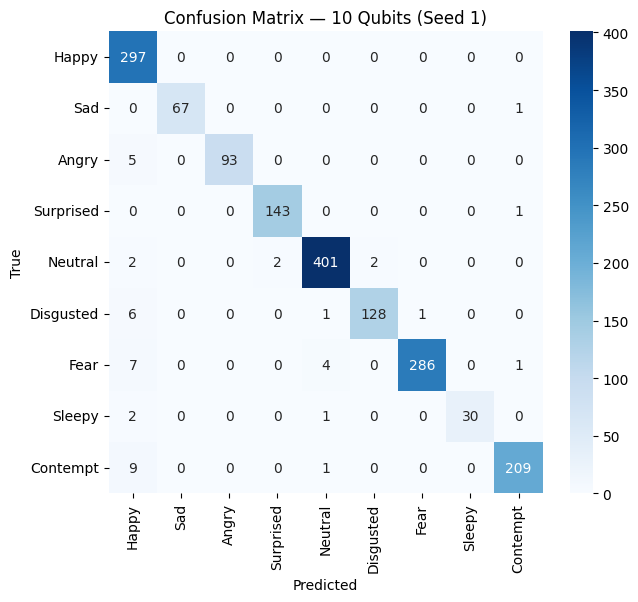

 Running Quantum CNN for Seed = 2
Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


213/213 - 3s - 16ms/step - accuracy: 0.2312 - loss: 2.3354 - val_accuracy: 0.3494 - val_loss: 1.7895
Epoch 2/250
213/213 - 2s - 11ms/step - accuracy: 0.3047 - loss: 1.9149 - val_accuracy: 0.4341 - val_loss: 1.6566
Epoch 3/250
213/213 - 2s - 10ms/step - accuracy: 0.3559 - loss: 1.7493 - val_accuracy: 0.4582 - val_loss: 1.5130
Epoch 4/250
213/213 - 3s - 14ms/step - accuracy: 0.3924 - loss: 1.6628 - val_accuracy: 0.5082 - val_loss: 1.4996
Epoch 5/250
213/213 - 2s - 10ms/step - accuracy: 0.4312 - loss: 1.5550 - val_accuracy: 0.5453 - val_loss: 1.3286
Epoch 6/250
213/213 - 3s - 12ms/step - accuracy: 0.4624 - loss: 1.4410 - val_accuracy: 0.5829 - val_loss: 1.2141
Epoch 7/250
213/213 - 3s - 12ms/step - accuracy: 0.4688 - loss: 1.3798 - val_accuracy: 0.6241 - val_loss: 1.1064
Epoch 8/250
213/213 - 2s - 10ms/step - accuracy: 0.5312 - loss: 1.2841 - val_accuracy: 0.6124 - val_loss: 1.1034
Epoch 9/250
213/213 - 3s - 14ms/step - accuracy: 0.5453 - loss: 1.1938 - val_accuracy: 0.6653 - val_loss: 0.

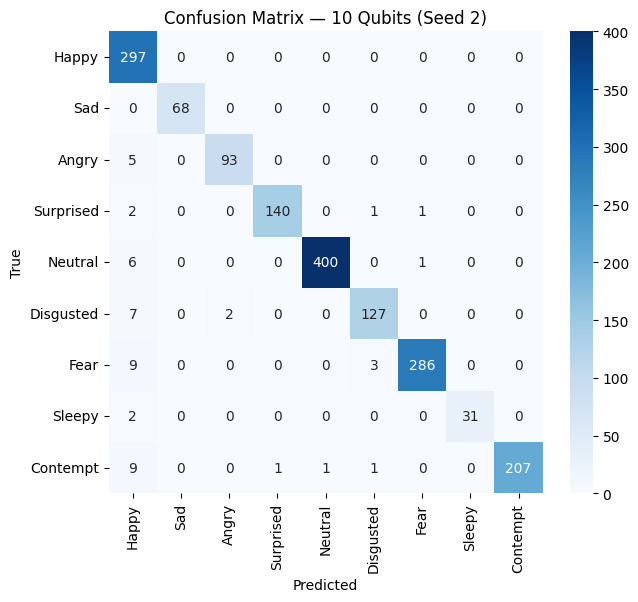

 Running Quantum CNN for Seed = 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 3s - 16ms/step - accuracy: 0.2224 - loss: 2.3169 - val_accuracy: 0.3276 - val_loss: 1.8087
Epoch 2/250
213/213 - 2s - 10ms/step - accuracy: 0.3041 - loss: 1.9186 - val_accuracy: 0.3865 - val_loss: 1.6551
Epoch 3/250
213/213 - 2s - 11ms/step - accuracy: 0.3312 - loss: 1.8039 - val_accuracy: 0.4306 - val_loss: 1.5737
Epoch 4/250
213/213 - 3s - 12ms/step - accuracy: 0.4000 - loss: 1.6597 - val_accuracy: 0.5194 - val_loss: 1.3623
Epoch 5/250
213/213 - 3s - 13ms/step - accuracy: 0.4365 - loss: 1.5685 - val_accuracy: 0.5300 - val_loss: 1.2910
Epoch 6/250
213/213 - 2s - 11ms/step - accuracy: 0.4594 - loss: 1.4477 - val_accuracy: 0.6000 - val_loss: 1.1729
Epoch 7/250
213/213 - 2s - 11ms/step - accuracy: 0.4924 - loss: 1.3747 - val_accuracy: 0.6329 - val_loss: 1.0974
Epoch 8/250
213/213 - 2s - 12ms/step - accuracy: 0.5100 - loss: 1.3055 - val_accuracy: 0.6524 - val_loss: 1.0359
Epoch 9/250
213/213 - 2s - 11ms/step - accuracy: 0.5629 - loss: 1.1915 - val_accuracy: 0.7024 - 

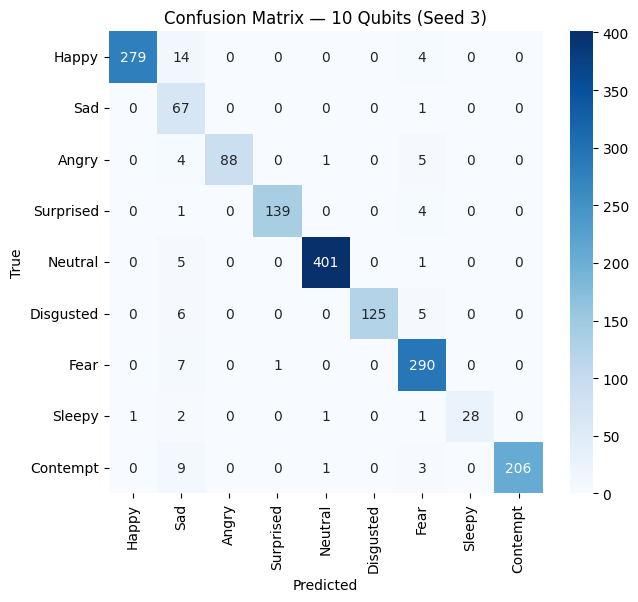

 Running Quantum CNN for Seed = 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 3s - 15ms/step - accuracy: 0.2235 - loss: 2.3168 - val_accuracy: 0.3288 - val_loss: 1.8211
Epoch 2/250
213/213 - 2s - 10ms/step - accuracy: 0.2971 - loss: 1.9349 - val_accuracy: 0.4241 - val_loss: 1.6292
Epoch 3/250
213/213 - 2s - 10ms/step - accuracy: 0.3624 - loss: 1.7335 - val_accuracy: 0.4700 - val_loss: 1.5009
Epoch 4/250
213/213 - 2s - 11ms/step - accuracy: 0.4047 - loss: 1.6355 - val_accuracy: 0.5353 - val_loss: 1.3867
Epoch 5/250
213/213 - 3s - 14ms/step - accuracy: 0.4494 - loss: 1.5432 - val_accuracy: 0.5829 - val_loss: 1.2274
Epoch 6/250
213/213 - 2s - 10ms/step - accuracy: 0.4900 - loss: 1.3927 - val_accuracy: 0.6118 - val_loss: 1.1527
Epoch 7/250
213/213 - 2s - 10ms/step - accuracy: 0.5265 - loss: 1.3105 - val_accuracy: 0.6200 - val_loss: 1.0977
Epoch 8/250
213/213 - 2s - 10ms/step - accuracy: 0.5318 - loss: 1.2527 - val_accuracy: 0.6541 - val_loss: 1.0146
Epoch 9/250
213/213 - 2s - 10ms/step - accuracy: 0.5700 - loss: 1.1602 - val_accuracy: 0.6929 - 

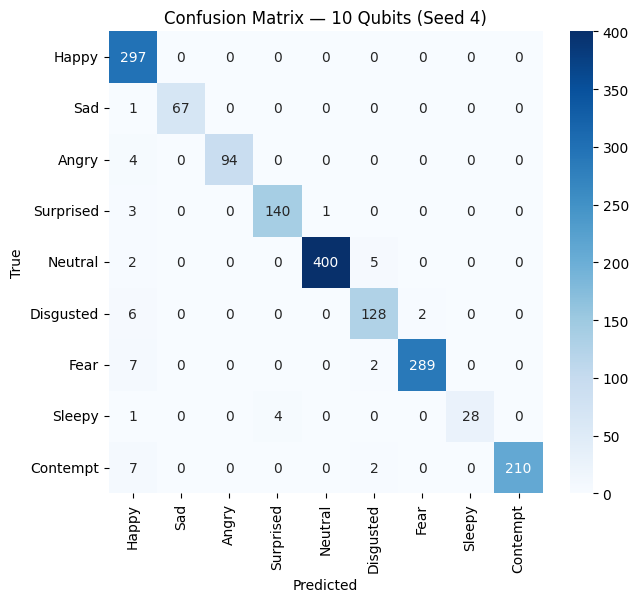


Final Summary Across Seeds (12 Qubits)
   Seed  Accuracy       AUC        F1
0     0  0.961176  0.999055  0.959887
1     1  0.972941  0.999362  0.972543
2     2  0.970000  0.999313  0.970850
3     3  0.954706  0.997873  0.934037
4     4  0.972353  0.999469  0.966732

Mean ± Std and 95% CI:
  Accuracy : 0.9662 ± 0.0080  (95% CI: [0.9563, 0.9762])
  Macro AUC: 0.9990 ± 0.0007  (95% CI: [0.9982, 0.9998])
  Macro F1 : 0.9608 ± 0.0157  (95% CI: [0.9413, 0.9804])


In [6]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st


n_qubits = 10
num_classes = len(EMOTIONS)
seeds = [0, 1, 2, 3, 4]


results = []

for seed in seeds:
    print(f" Running Quantum CNN for Seed = {seed}")

    # Fix random seed for reproducibility
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Build and train model
    model = build_model(q_train_images.shape[1:], num_classes)
    history = model.fit(q_train_images, train_labels, validation_data=(q_test_images, test_labels),
                        epochs=250, batch_size=8, verbose=2)

    # Predictions
    y_pred_prob = model.predict(q_test_images)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Accuracy
    acc = np.mean(y_pred == test_labels)

    # One-hot encode labels for AUC
    y_true_onehot = keras.utils.to_categorical(test_labels, num_classes=num_classes)
    try:
        macro_auc = roc_auc_score(y_true_onehot, y_pred_prob, multi_class='ovr', average='macro')
    except ValueError:
        macro_auc = np.nan

    # Macro F1
    macro_f1 = f1_score(test_labels, y_pred, average='macro')

    print(f"\nSeed {seed} Results:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro AUC: {macro_auc:.4f}")
    print(f"  Macro F1 : {macro_f1:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(test_labels, y_pred, target_names=EMOTIONS, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title(f'Confusion Matrix — 10 Qubits (Seed {seed})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Store results
    results.append({
        'Seed': seed,
        'Accuracy': acc,
        'AUC': macro_auc,
        'F1': macro_f1
    })


results_df = pd.DataFrame(results)
mean_acc, std_acc = results_df['Accuracy'].mean(), results_df['Accuracy'].std(ddof=1)
mean_auc, std_auc = results_df['AUC'].mean(), results_df['AUC'].std(ddof=1)
mean_f1, std_f1 = results_df['F1'].mean(), results_df['F1'].std(ddof=1)

# 95% Confidence Intervals
ci_acc = st.t.interval(0.95, len(results_df)-1, loc=mean_acc, scale=st.sem(results_df['Accuracy']))
ci_auc = st.t.interval(0.95, len(results_df)-1, loc=mean_auc, scale=st.sem(results_df['AUC']))
ci_f1 = st.t.interval(0.95, len(results_df)-1, loc=mean_f1, scale=st.sem(results_df['F1']))

print("\nFinal Summary Across Seeds (12 Qubits)")
print(results_df)
print(f"\nMean ± Std and 95% CI:")
print(f"  Accuracy : {mean_acc:.4f} ± {std_acc:.4f}  (95% CI: [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}])")
print(f"  Macro AUC: {mean_auc:.4f} ± {std_auc:.4f}  (95% CI: [{ci_auc[0]:.4f}, {ci_auc[1]:.4f}])")
print(f"  Macro F1 : {mean_f1:.4f} ± {std_f1:.4f}  (95% CI: [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}])")
